
# Non-Hermitian many-body localization as a quantum reservoir
### Classically-simulated prototype (N=8 spins)  

**The gap this targets:** non-Hermitian MBL (real-vs-complex spectral transitions tied to
localization, PT-symmetry breaking, the non-Hermitian skin effect) is an active field on
its own. Reservoir computing / ML-based phase diagnosis is an active field on its own.
A literature check found no paper combining them : non-Hermitian skin-effect reservoirs
that exist so far are either architectural (a QNN built to *have* a skin effect) or
free-fermion ("Fermi skin" on real hardware), not an *interacting, disordered* non-Hermitian
chain used as a reservoir to diagnose its own localization transition.

**Same caveat as the Hermitian version:** this notebook simulates everything classically
(exact diagonalization, N=8). It cannot and does not demonstrate quantum advantage. What
it *can* demonstrate is a real, reproducible methodological point : and a non-Hermitian-specific
one that has no analog in the Hermitian case  


In [ ]:
!pip install shap

In [ ]:

import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.linalg import eig
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sx = np.array([[0, 1], [1, 0]], dtype=complex) / 2
sy = np.array([[0, -1j], [1j, 0]], dtype=complex) / 2
sz = np.array([[1, 0], [0, -1]], dtype=complex) / 2
sp, sm = sx + 1j * sy, sx - 1j * sy
I2 = np.eye(2, dtype=complex)



## 1. The model : an interacting, disordered Hatano–Nelson chain

$$ H = \sum_{\langle i,j\rangle} \Big[J e^{g} S^+_i S^-_j + J e^{-g} S^-_i S^+_j + J\Delta\, S^z_i S^z_j\Big] + \sum_i h_i S^z_i,\qquad h_i\sim U[-W,W] $$

on a **ring** (periodic boundary conditions), with non-reciprocal hopping controlled by $g$
($g=0$ recovers the ordinary Hermitian MBL chain).

 **the non-Hermitian analog of the symmetry-sector
pitfall from before :** under *open* boundary conditions, this exact asymmetric-hopping
construction can be removed entirely by a (non-unitary) similarity transform : a textbook
fact about the single-particle Hatano–Nelson model that survives in the many-body case
because the $S^z_iS^z_j$ interaction is diagonal in the same basis the transform acts on.  The non-Hermitian content of this model is a **ring-only**
effect : that's why PBC is hard-coded below, not a stylistic choice.

We track total $S^z$ : still an exact symmetry, conserved by both the hopping and the
interaction term , and again restrict level-statistics diagnostics to the
$S^z=0$ sector.


In [ ]:

def op_on_site(op, site, N):
    mats = [I2] * N
    mats[site] = op
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out

def build_H_NH(h, N, g, J=1.0, Delta=1.0, pbc=True):
    dim = 2 ** N
    H = np.zeros((dim, dim), dtype=complex)
    Sp = [op_on_site(sp, i, N) for i in range(N)]
    Sm = [op_on_site(sm, i, N) for i in range(N)]
    Sz = [op_on_site(sz, i, N) for i in range(N)]
    bonds = list(range(N - 1)) + ([N - 1] if pbc else [])
    for i in bonds:
        j = (i + 1) % N
        H += J * np.exp(g) * Sp[i] @ Sm[j] + J * np.exp(-g) * Sm[i] @ Sp[j]
        H += J * Delta * Sz[i] @ Sz[j]
    for i in range(N):
        H += h[i] * Sz[i]
    return H, Sz

def sector_indices(N):
    dim = 2 ** N
    return [i for i in range(dim) if bin(i).count('1') == N // 2]

def neel_index(N):
    return sum((1 if i % 2 == 0 else 0) << i for i in range(N))



## 2. Ground truth: the real-complex (RC) spectral transition

For this time reversal symmetric non-Hermitian family, the literature (Hamazaki et al.,
and follow-ups on long-range models) shows the fraction of **real** eigenvalues acts as an
order parameter that tracks the ergodic MBL transition: strong disorder suppresses the
imaginary parts of the spectrum and restores a real spectrum, even though $g\neq0$.
We use the disorder-averaged real fraction $\overline{f_{\rm real}}(W)$ and its crossing
through 0.5 as the (finite-size) pseudo-critical point, exactly mirroring how we used the
level-statistics ratio $\bar r(W)$ in the Hermitian.


In [ ]:
def build_dataset(
    N=10,
    g=0.3,
    W_list=(0.2,0.5,1,1.5,2,3,4,6,10),
    n_real=30,
    seed=0,
    meas_sites=None,
    meas_times=(0,1,2,4,8),
    include_survival=True,
    cond_threshold=1e10
):

    rng = np.random.default_rng(seed)

    if meas_sites is None:
        meas_sites = [0, N//2]

    dim = 2**N
    idx0 = neel_index(N)
    sec_idx = sector_indices(N)

    rows_feat = []
    rows_oracle = []
    rows_fr = []
    rows_W = []

    skipped_ep = 0

    for W in W_list:

        for _ in range(n_real):

            h = rng.uniform(-W, W, size=N)

            H, Sz = build_H_NH(h, N, g)


            # Ground-truth diagnostic (Sz = 0 sector)


            Hsub = H[np.ix_(sec_idx, sec_idx)]

            evals_sub = eig(Hsub, right=False)

            frac_real = np.mean(np.abs(evals_sub.imag) < 1e-8)


            # Reservoir dynamics


            evals, V = eig(H)

            #   Numerical stability guard
            condV = np.linalg.cond(V)

            if not np.isfinite(condV) or condV > cond_threshold:
                skipped_ep += 1
                continue

            psi0 = np.zeros(dim, dtype=complex)
            psi0[idx0] = 1.0

            c = np.linalg.solve(V, psi0)

            feat = []

            for tt in meas_times:

                psi_t = V @ (np.exp(-1j * evals * tt) * c)

                norm2 = np.real(psi_t.conj() @ psi_t)

                if include_survival:
                    feat.append(np.log(norm2 + 1e-300))

                for site in meas_sites:

                    val = (
                        np.real(psi_t.conj() @ (Sz[site] @ psi_t))
                        / norm2
                    )

                    feat.append(val)

            oracle = [
                h.mean(),
                h.std(),
                h.min(),
                h.max()
            ]

            rows_feat.append(feat)
            rows_oracle.append(oracle)
            rows_fr.append(frac_real)
            rows_W.append(W)

    print(
        f"Skipped {skipped_ep} realization(s) "
        f"due to ill-conditioned eigenvector matrices "
        f"(cond(V) > {cond_threshold:.1e})."
    )

    return (
        np.array(rows_feat),
        np.array(rows_oracle),
        np.array(rows_fr),
        np.array(rows_W)
    )


## 3. Reservoir features: local measurements *and* the survival-probability channel

Non-Hermitian dynamics has something the Hermitian reservoir doesn't: norm isn't conserved.
Physically this corresponds to a continuously-monitored open system, conditioned on no
quantum jump having occurred (a standard "no-click" trajectory interpretation) — the decay
or growth of the post-selection probability over time is itself an experimentally
accessible, model-free witness of which phase you're in (bounded/oscillatory in the
real-spectrum/localized phase, exponential in the complex-spectrum/delocalized phase),
with no analog in the ordinary unitary-MBL setting. We include it as one of the reservoir
output channels alongside the same local $\langle S^z_i(t)\rangle$ measurements as before.

Same three-way comparison as the Hermitian notebook, for the same reasons:
- **reservoir** — quench dynamics, a couple of sites, plus the survival-probability channel.
- **oracle** — direct access to the disorder values (unrealistic upper bound).
- **no-dynamics control** — same channels at $t=0$ only (deterministic, so should sit at
  the majority-class baseline if the pipeline has no leak).


Skipped 0 realization(s) due to ill-conditioned eigenvector matrices (cond(V) > 1.0e+10).
Majority-class baseline             Accuracy = 0.556
Reservoir (dynamics + survival)     Accuracy = 0.938
Cross-validation (5-fold): 0.941 ± 0.022
Oracle (direct disorder statistics) Accuracy = 0.963
Cross-validation (5-fold): 0.981 ± 0.017
No-dynamics control                 Accuracy = 0.543
Cross-validation (5-fold): 0.533 ± 0.043


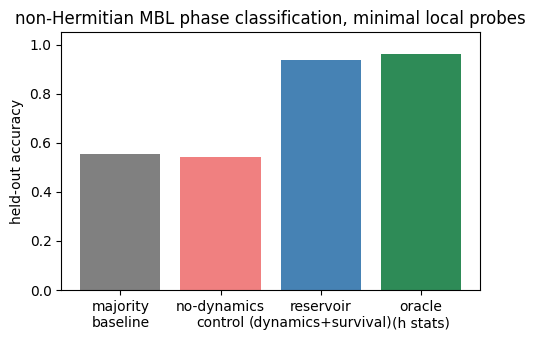

In [ ]:
N = 8
g = 0.3

# Call build_dataset to generate the data
X_res, X_oracle, y_fr, y_W = build_dataset(
    N=N,
    g=g,
    n_real=30,
)

# Determine W_star from the fraction of real eigenvalues
# This involves grouping y_fr by y_W and finding the W where the mean y_fr crosses 0.5
W_unique = np.sort(np.unique(y_W))
fr_mean = []
for W_val in W_unique:
    fr_mean.append(np.mean(y_fr[y_W == W_val]))


fr_mean = np.array(fr_mean)

# Find the first W where fr_mean drops below 0.5 (or rises above, depending on the ordering)
W_star = None
# Assuming fr_mean is generally decreasing with W for a transition from real to complex
for i in range(len(W_unique) - 1):
    if (fr_mean[i] >= 0.5 and fr_mean[i+1] < 0.5) or (fr_mean[i] < 0.5 and fr_mean[i+1] >= 0.5):
        # Linear interpolation
        w1, w2 = W_unique[i], W_unique[i+1]
        fr1, fr2 = fr_mean[i], fr_mean[i+1]
        W_star = w1 + (0.5 - fr1) * (w2 - w1) / (fr2 - fr1)
        break


if W_star is None:

    W_star = (W_unique.min() + W_unique.max()) / 2
    print(f"Warning: Could not find a clear 0.5 crossing for frac_real. Using W_star = {W_star:.2f} as a fallback.")

# Define y_phase based on W_star
# Assuming 'localized' corresponds to W > W_star
y_phase = (y_W > W_star).astype(int)

n_feat_per_t = 1 + 2
X_static = X_res[:, :n_feat_per_t]


#   classifier evaluation


def eval_classifier(Xf, name, cv=5):
    """
    Train a Random Forest classifier and return everything needed
    for downstream analysis.

    Returns

    results : dict
        Contains:
            accuracy
            cv_mean
            cv_std
            classifier
            scaler
            X_test
            y_test
            y_pred
            y_prob
    """


    # Train / Test split

    Xtr, Xte, ytr, yte = train_test_split(
        Xf,
        y_phase,
        test_size=0.30,
        random_state=0,
        stratify=y_phase
    )


    # Standardization

    scaler = StandardScaler()

    Xtr_sc = scaler.fit_transform(Xtr)
    Xte_sc = scaler.transform(Xte)


    # Random Forest Classifier

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=0,
        class_weight="balanced"
    )

    clf.fit(Xtr_sc, ytr)


    # Predictions

    y_pred = clf.predict(Xte_sc)

    y_prob = clf.predict_proba(Xte_sc)[:, 1]

    acc = accuracy_score(yte, y_pred)

    print(f"{name:35s} Accuracy = {acc:.3f}")


    # Cross Validation

    from sklearn.pipeline import Pipeline

    pipe = Pipeline([
       ("scaler", StandardScaler()),
       ("rf", RandomForestClassifier(
             n_estimators=300,
             random_state=0,
             class_weight="balanced"))
    ])

    cv_scores = cross_val_score(
       pipe,
       Xf,
       y_phase,
       cv=StratifiedKFold(
          n_splits=cv,
          shuffle=True,
          random_state=0
     ),

        scoring="accuracy"
    )

    print(
        f"Cross-validation ({cv}-fold): "
        f"{cv_scores.mean():.3f} \u00b1 {cv_scores.std():.3f}"
    )

    return {
        "accuracy": acc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "classifier": clf,
        "scaler": scaler,
        "X_test": Xte_sc,
        "y_test": yte,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

majority_baseline = max(y_phase.mean(), 1 - y_phase.mean())

print(f"{'Majority-class baseline':35s} Accuracy = {majority_baseline:.3f}")

res_results = eval_classifier(
    X_res,
    "Reservoir (dynamics + survival)"
)

oracle_results = eval_classifier(
    X_oracle,
    "Oracle (direct disorder statistics)"
)

static_results = eval_classifier(
    X_static,
    "No-dynamics control"
)

acc_res = res_results["accuracy"]
acc_oracle = oracle_results["accuracy"]
acc_static = static_results["accuracy"]

fig, ax = plt.subplots(figsize=(5, 3.5))
names = ['majority\nbaseline', 'no-dynamics\ncontrol', 'reservoir\n(dynamics+survival)', 'oracle\n(h stats)']
vals = [majority_baseline, acc_static, acc_res, acc_oracle]
ax.bar(names, vals, color=['gray', 'lightcoral', 'steelblue', 'seagreen'])
ax.set_ylim(0, 1.05); ax.set_ylabel('held-out accuracy')
ax.set_title('non-Hermitian MBL phase classification, minimal local probes')
plt.tight_layout(); plt.show()


RESERVOIR CLASSIFIER PERFORMANCE

Classification Report

              precision    recall  f1-score   support

           0      0.955     0.933     0.944        45
           1      0.919     0.944     0.932        36

    accuracy                          0.938        81
   macro avg      0.937     0.939     0.938        81
weighted avg      0.939     0.938     0.938        81



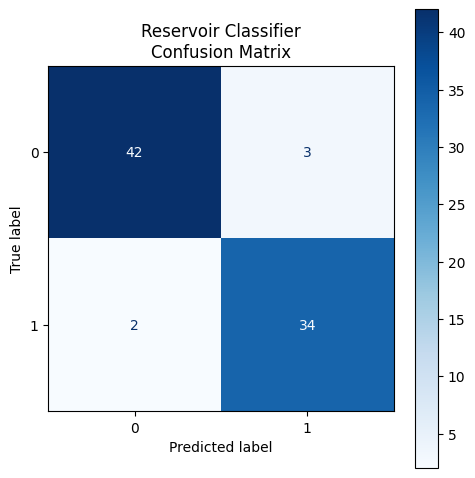

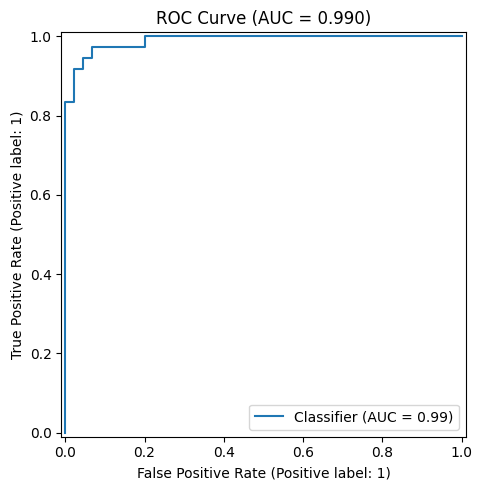

ROC-AUC Score : 0.990


In [ ]:

#   evaluation of the Reservoir Classifier


print("=" * 70)
print("RESERVOIR CLASSIFIER PERFORMANCE")
print("=" * 70)

print("\nClassification Report\n")
print(classification_report(
    res_results["y_test"],
    res_results["y_pred"],
    digits=3
))


# Confusion Matrix


fig, ax = plt.subplots(figsize=(5,5))

ConfusionMatrixDisplay.from_predictions(
    res_results["y_test"],
    res_results["y_pred"],
    cmap="Blues",
    ax=ax
)

ax.set_title("Reservoir Classifier\nConfusion Matrix")

plt.tight_layout()
plt.show()


# ROC Curve


auc = roc_auc_score(
    res_results["y_test"],
    res_results["y_prob"]
)

fig, ax = plt.subplots(figsize=(6,5))

RocCurveDisplay.from_predictions(
    res_results["y_test"],
    res_results["y_prob"],
    ax=ax
)

ax.set_title(f"ROC Curve (AUC = {auc:.3f})")

plt.tight_layout()
plt.show()

print(f"ROC-AUC Score : {auc:.3f}")

CLASSICAL ML BENCHMARK
Logistic Regression      : 0.952 ± 0.009
SVM (RBF)                : 0.956 ± 0.019
Random Forest            : 0.941 ± 0.022
MLP                      : 0.944 ± 0.033


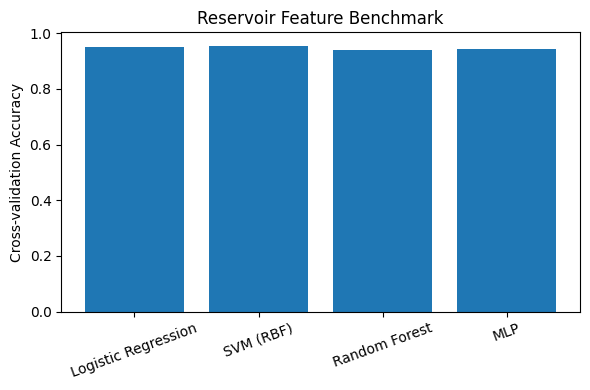

In [ ]:

# Benchmark against Classical ML Models


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "SVM (RBF)":
        SVC(kernel="rbf", probability=True),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=0,
            class_weight="balanced"),

    "MLP":
        MLPClassifier(
            hidden_layer_sizes=(64,32),
            max_iter=3000,
            random_state=0)
}

print("="*70)
print("CLASSICAL ML BENCHMARK")
print("="*70)

benchmark_results = {}

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    scores = cross_val_score(
        pipe,
        X_res,
        y_phase,
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=0),
        scoring="accuracy"
    )

    benchmark_results[name] = scores.mean()

    print(f"{name:25s}: {scores.mean():.3f} ± {scores.std():.3f}")

plt.figure(figsize=(6,4))

plt.bar(
    benchmark_results.keys(),
    benchmark_results.values()
)

plt.ylabel("Cross-validation Accuracy")

plt.title("Reservoir Feature Benchmark")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [ ]:
print(np.mean(res_results["X_test"]))
print(np.std(res_results["X_test"]))

0.014667618920105518
0.9575391486776311


In [ ]:
for sigma in noise_levels:

    X_noisy = X_test + rng.normal(
        0,
        sigma,
        X_test.shape
    )



    y_pred = clf.predict(X_noisy)

    acc = accuracy_score(y_test, y_pred)

    noise_acc.append(acc)

    print(f"Noise σ = {sigma:.2f} : Accuracy = {acc:.3f}")

NameError: name 'noise_levels' is not defined

In [ ]:

# Feature Importance Analysis

meas_times = (0, 1, 2, 4, 8)
rf = res_results["classifier"]

importance = rf.feature_importances_

print("=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

print(f"Total number of features : {len(importance)}")


# Raw Feature Importance


plt.figure(figsize=(12,4))

plt.bar(
    np.arange(len(importance)),
    importance,
    color="steelblue"
)

plt.xlabel("Feature Index", fontsize=12)
plt.ylabel("Importance", fontsize=12)
plt.title("Random Forest Feature Importance")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Top Features


top = np.argsort(importance)[::-1]

print("\nTop 10 Features\n")

for rank, idx in enumerate(top[:10],1):

    t_index = idx // 3

    obs = idx % 3

    if obs == 0:
        observable = "log(Survival Probability)"
    elif obs == 1:
        observable = f"<Sz(site {0})>"
    else:
        observable = f"<Sz(site {N//2})>"

    print(
        f"{rank:2d}. Feature {idx:2d} | "
        f"Time = {meas_times[t_index]:2d} | "
        f"{observable:28s} | "
        f"Importance = {importance[idx]:.5f}"
    )


# Importance grouped by evolution time


importance_time = importance.reshape(len(meas_times),3)

labels = [
    "Survival",
    f"Sz({0})",
    f"Sz({N//2})"
]

plt.figure(figsize=(8,5))

bottom = np.zeros(len(meas_times))

for j in range(3):

    plt.bar(
        np.arange(len(meas_times)),
        importance_time[:,j],
        bottom=bottom,
        label=labels[j]
    )

    bottom += importance_time[:,j]

plt.xticks(
    np.arange(len(meas_times)),
    meas_times
)

plt.xlabel("Evolution Time")

plt.ylabel("Total Feature Importance")

plt.title("Reservoir Information Content vs Evolution Time")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:

# SHAP Explainability


import shap

explainer = shap.TreeExplainer(res_results["classifier"])

shap_values = explainer.shap_values(
    res_results["X_test"]
)

print("="*70)
print("SHAP FEATURE IMPORTANCE")
print("="*70)

shap.summary_plot(
    shap_values,
    res_results["X_test"],
    show=False
)

plt.tight_layout()

plt.show()

In [ ]:

# ML Probability vs Disorder Strength


# Probability that a sample belongs to the localized phase

clf = res_results["classifier"]
scaler = res_results["scaler"]

W_unique = np.sort(np.unique(y_W))

ml_prob = []
ml_std = []

for W in W_unique:

    mask = (y_W == W)

    XW = scaler.transform(X_res[mask])

    prob = clf.predict_proba(XW)[:,1]

    ml_prob.append(prob.mean())
    ml_std.append(prob.std())

ml_prob = np.array(ml_prob)
ml_std = np.array(ml_std)

plt.figure(figsize=(6,4))

plt.errorbar(
    W_unique,
    ml_prob,
    yerr=ml_std,
    fmt='o-',
    capsize=4,
    linewidth=2,
    label="Reservoir ML"
)

plt.axvline(
    W_star,
    color='red',
    linestyle='--',
    label=f"$W^*={W_star:.2f}$"
)

plt.xlabel("Disorder Strength $W$")
plt.ylabel("Mean Localization Probability")
plt.title("Reservoir Classifier Confidence")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:

# Compare ML Prediction with Physical Order Parameter


fig, ax1 = plt.subplots(figsize=(6,4))

ax1.plot(
    W_unique,
    fr_mean,
    'o-',
    color='tab:blue',
    linewidth=2,
    label="Fraction of Real Eigenvalues"
)

ax1.set_xlabel("Disorder Strength $W$")
ax1.set_ylabel("Fraction of Real Eigenvalues",
               color='tab:blue')

ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()

ax2.plot(
    W_unique,
    ml_prob,
    's--',
    color='tab:red',
    linewidth=2,
    label="ML Localization Probability"
)

ax2.set_ylabel(
    "ML Localization Probability",
    color='tab:red'
)

ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.axvline(
    W_star,
    color='black',
    linestyle=':',
    linewidth=2
)

plt.title("Physical Transition vs Reservoir Prediction")

fig.tight_layout()

plt.show()


In [ ]:
print("="*70)
print("SURVIVAL CHANNEL ABLATION")
print("="*70)

X_res_spin, _, _, _ = build_dataset(
    N=N,
    g=g,
    n_real=30,
    meas_times=meas_times,
    include_survival=False
)

spin_results = eval_classifier(
    X_res_spin,
    "Reservoir without Survival Channel"
)

print("\nAccuracy Comparison")

print(f"Full Reservoir      : {acc_res:.3f}")
print(f"Spin-only Reservoir : {spin_results['accuracy']:.3f}")

In [ ]:
labels = [
    "Spin Only",
    "Full Reservoir"
]

acc = [
    spin_results["accuracy"],
    acc_res
]

plt.figure(figsize=(5,4))

plt.bar(labels, acc)

plt.ylabel("Accuracy")

plt.title("Contribution of Survival Probability")

plt.ylim(0,1)

plt.grid(alpha=0.3)

plt.show()

In [ ]:

# Generalization Across Interaction Strength


print("="*70)
print("GENERALIZATION ACROSS INTERACTION STRENGTH")
print("="*70)

g_train = 0.30

g_test_list = [0.10,0.20,0.40,0.50]

X_train, _, fr_train, W_train = build_dataset(
    N=N,
    g=g_train,
    n_real=30
)

y_train = (W_train > W_star).astype(int)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=0,
        class_weight="balanced"))
])

pipe.fit(X_train,y_train)

generalization = []

for gtest in g_test_list:

    X_test, _, fr_test, W_test = build_dataset(
        N=N,
        g=gtest,
        n_real=30
    )

    y_test = (W_test > W_star).astype(int)

    acc = pipe.score(
        X_test,
        y_test
    )

    generalization.append(acc)

    print(f"Train g={g_train:.2f}  Test g={gtest:.2f} : {acc:.3f}")

plt.figure(figsize=(6,4))

plt.plot(
    g_test_list,
    generalization,
    "o-",
    linewidth=2
)

plt.xlabel("Test Interaction Strength g")

plt.ylabel("Accuracy")

plt.title("Cross-g Generalization")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:

# Reservoir Separability using PCA


from sklearn.decomposition import PCA

print("="*70)
print("RESERVOIR SEPARABILITY (PCA)")
print("="*70)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

# Reduce to two principal components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance (PC1): {100*pca.explained_variance_ratio_[0]:.2f}%")
print(f"Explained variance (PC2): {100*pca.explained_variance_ratio_[1]:.2f}%")
print(f"Total explained variance: {100*np.sum(pca.explained_variance_ratio_):.2f}%")

plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[y_phase==0,0],
    X_pca[y_phase==0,1],
    alpha=0.7,
    label="Delocalized"
)

plt.scatter(
    X_pca[y_phase==1,0],
    X_pca[y_phase==1,1],
    alpha=0.7,
    label="Localized"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Reservoir Feature Space (PCA)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
pip install umap-learn

In [ ]:

# Reservoir Separability using UMAP


import umap.umap_ as umap

print("="*70)
print("RESERVOIR SEPARABILITY (UMAP)")
print("="*70)

embedding = umap.UMAP(
    n_neighbors=15,
    min_dist=0.15,
    random_state=0
)

X_umap = embedding.fit_transform(X_scaled)

plt.figure(figsize=(6,5))

plt.scatter(
    X_umap[y_phase==0,0],
    X_umap[y_phase==0,1],
    alpha=0.7,
    label="Delocalized"
)

plt.scatter(
    X_umap[y_phase==1,0],
    X_umap[y_phase==1,1],
    alpha=0.7,
    label="Localized"
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.title("Reservoir Feature Space (UMAP)")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:

# Minimal Observable Analysis


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

print("="*70)
print("MINIMAL OBSERVABLE ANALYSIS")
print("="*70)


# Feature indices
# Feature order:
# [logP, Sz(0), Sz(mid)] repeated for each measurement time

n_times = 5

logP_idx = [3*i for i in range(n_times)]
sz0_idx  = [3*i + 1 for i in range(n_times)]
szm_idx  = [3*i + 2 for i in range(n_times)]

early_idx = [0,1,2,3,4,5]            # t = 0,1
late_idx  = [9,10,11,12,13,14]       # t = 4,8

feature_sets = {
    "Full Reservoir"      : np.arange(X_res.shape[1]),
    "Survival only"       : logP_idx,
    "Sz(0) only"          : sz0_idx,
    "Sz(mid) only"        : szm_idx,
    "Early times only"    : early_idx,
    "Late times only"     : late_idx,
}

results = {}

for name, idx in feature_sets.items():

    X = X_res[:, idx]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_phase,
        test_size=0.25,
        stratify=y_phase,
        random_state=42
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=0
        ))
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

    print(f"{name:25s}: {acc:.3f}")


# Plot


plt.figure(figsize=(7,4))

plt.bar(results.keys(), results.values())

plt.ylabel("Test Accuracy")

plt.title("Minimal Observable Study")

plt.xticks(rotation=25)

plt.ylim(0.5,1.0)

plt.tight_layout()

plt.show()

In [ ]:

# Time-Resolved Reservoir Information


print("="*70)
print("TIME-RESOLVED RESERVOIR INFORMATION")
print("="*70)

times = [0,1,2,4,8]

accuracy_vs_time = []

for i,t in enumerate(times):

    cols = [3*i,3*i+1,3*i+2]

    X = X_res[:,cols]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_phase,
        test_size=0.25,
        stratify=y_phase,
        random_state=42
    )

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=0
        ))
    ])

    pipe.fit(X_train,y_train)

    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test,pred)

    accuracy_vs_time.append(acc)

    print(f"t = {t:2d} : Accuracy = {acc:.3f}")

plt.figure(figsize=(6,4))

plt.plot(
    times,
    accuracy_vs_time,
    'o-',
    linewidth=2,
    markersize=8
)

plt.xlabel("Measurement Time")

plt.ylabel("Classification Accuracy")

plt.title("Information Developed by the Quantum Reservoir")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:

# Feature Space Separation vs Time


print("="*70)
print("FEATURE-SPACE SEPARATION")
print("="*70)

times = [0,1,2,4,8]

distance = []

for i in range(len(times)):

    cols = [3*i,3*i+1,3*i+2]

    X = X_res[:,cols]

    loc = X[y_phase==1]
    deloc = X[y_phase==0]

    mu_loc = loc.mean(axis=0)
    mu_deloc = deloc.mean(axis=0)

    d = np.linalg.norm(mu_loc-mu_deloc)

    distance.append(d)

    print(f"t={times[i]:2d}   distance = {d:.4f}")

plt.figure(figsize=(6,4))

plt.plot(
    times,
    distance,
    'o-',
    linewidth=2,
    markersize=8
)

plt.xlabel("Measurement Time")

plt.ylabel("Distance Between Phase Centroids")

plt.title("Development of Reservoir Feature Separation")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:

# Finite-Size Scaling of the Pseudo-Critical Disorder


print("="*70)
print("FINITE-SIZE SCALING")
print("="*70)

sizes = [8, 10]

W_star_list = []

for Nsize in sizes:

    print(f"\nRunning N = {Nsize}")

    X_tmp, Xo_tmp, y_fr_tmp, y_W_tmp = build_dataset(
        N=Nsize,
        g=0.3,
        n_real=30
    )

    W_grid_tmp = np.unique(y_W_tmp)

    fr_mean = np.array([
        y_fr_tmp[y_W_tmp==W].mean()
        for W in W_grid_tmp
    ])

    above = fr_mean > 0.5

    if above.all() or (~above).all():

        W_star_tmp = np.median(W_grid_tmp)

    else:

        cross = np.where(~above[:-1] & above[1:])[0][0]

        w1 = W_grid_tmp[cross]
        w2 = W_grid_tmp[cross+1]

        f1 = fr_mean[cross]
        f2 = fr_mean[cross+1]

        W_star_tmp = w1 + (0.5-f1)*(w2-w1)/(f2-f1)

    W_star_list.append(W_star_tmp)

    print(f"W*(N={Nsize}) = {W_star_tmp:.3f}")

plt.figure(figsize=(6,4))

plt.plot(
    sizes,
    W_star_list,
    'o-',
    linewidth=2,
    markersize=8
)

plt.xlabel("System Size N")

plt.ylabel("Pseudo-Critical Disorder $W^*$")

plt.title("Finite-Size Scaling")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Revised experimental suite — post-desk-rejection upgrade

This section adds the model/validation experiments required before rewriting the manuscript.

New questions:
1. Does the reservoir outperform the trivial disorder-strength control?
2. Does it predict continuous `f_real`, rather than only a binary label?
3. Which dynamical observables track the spectral diagnostic?
4. Does a classical nonlinear reservoir (ESN) explain the result equally well?
5. Are conclusions stable across independent seeds?
6. How sensitive are results to `g`, initial state, noise, training-set size, and system size?
7. Does the representation become more linearly separable during evolution?

The notebook deliberately does **not** assume quantum advantage.

In [ ]:
# ============================================================
# REVISED EXPERIMENT SUITE: imports + reproducibility
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from scipy.stats import pearsonr, spearmanr, ttest_rel, wilcoxon
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score, roc_auc_score, mean_absolute_error,
    mean_squared_error, r2_score
)
from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_val_score, train_test_split
)

REVISED_SEEDS = [42, 123, 321, 777, 999, 2024, 31415, 27182, 16180, 9001]
NOISE_LEVELS_REVISED = [0.0, 0.01, 0.05, 0.10, 0.20, 0.50]

print("Seeds:", REVISED_SEEDS)
print("Noise levels:", NOISE_LEVELS_REVISED)

## 1. Shortcut-control baselines

Because the binary label is thresholded by disorder strength `W`, `W` itself can be a strong shortcut. We therefore compare:

- `W only`
- disorder-summary statistics
- full reservoir features

under identical cross-validation protocols.

In [ ]:
def make_W_features(y_W):
    return np.asarray(y_W).reshape(-1, 1)

def evaluate_classifier_multiseed(X, y, seeds=REVISED_SEEDS, n_splits=5):
    X = np.asarray(X)
    y = np.asarray(y).astype(int)
    rows = []

    for seed in seeds:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("rf", RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=seed,
                n_jobs=-1
            ))
        ])

        acc = cross_val_score(clf, X, y, cv=skf, scoring="accuracy", n_jobs=-1)
        auc = cross_val_score(clf, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)

        rows.append({
            "seed": seed,
            "accuracy_mean": acc.mean(),
            "accuracy_fold_sd": acc.std(),
            "auc_mean": auc.mean(),
            "auc_fold_sd": auc.std()
        })
    return pd.DataFrame(rows)

try:
    revised_baseline_results = {
        "W only": evaluate_classifier_multiseed(make_W_features(y_W), y_phase),
        "Disorder statistics": evaluate_classifier_multiseed(X_oracle, y_phase),
        "Full reservoir": evaluate_classifier_multiseed(X_res, y_phase)
    }

    baseline_summary = pd.DataFrame({
        name: {
            "Accuracy_mean": df["accuracy_mean"].mean(),
            "Accuracy_SD_seeds": df["accuracy_mean"].std(ddof=1),
            "AUC_mean": df["auc_mean"].mean(),
            "AUC_SD_seeds": df["auc_mean"].std(ddof=1)
        }
        for name, df in revised_baseline_results.items()
    }).T

    display(baseline_summary.round(4))
except NameError as e:
    print("Run the original dataset-generation cells first. Missing:", e)

## 2. Continuous prediction of the spectral diagnostic

The binary task can be relatively easy because it reduces the problem to a threshold. The stronger test is:

`reservoir dynamics -> continuous f_real`.

We report R², MAE and RMSE.

In [ ]:
def evaluate_regression_multiseed(X, y, seeds=REVISED_SEEDS, n_splits=5):
    X = np.asarray(X)
    y = np.asarray(y, dtype=float)
    rows = []

    for seed in seeds:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

        models = {
            "Ridge": Pipeline([
                ("scaler", StandardScaler()),
                ("reg", Ridge(alpha=1.0))
            ]),
            "SVR-RBF": Pipeline([
                ("scaler", StandardScaler()),
                ("reg", SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.01))
            ]),
            "Random Forest": RandomForestRegressor(
                n_estimators=300, random_state=seed, n_jobs=-1
            )
        }

        for model_name, model in models.items():
            r2s, maes, rmses = [], [], []

            for tr, te in kf.split(X):
                m = clone(model)
                m.fit(X[tr], y[tr])
                pred = m.predict(X[te])
                r2s.append(r2_score(y[te], pred))
                maes.append(mean_absolute_error(y[te], pred))
                rmses.append(np.sqrt(mean_squared_error(y[te], pred)))

            rows.append({
                "seed": seed,
                "model": model_name,
                "R2": np.mean(r2s),
                "MAE": np.mean(maes),
                "RMSE": np.mean(rmses)
            })

    return pd.DataFrame(rows)

try:
    continuous_results = evaluate_regression_multiseed(X_res, y_fr)
    display(
        continuous_results.groupby("model")[["R2", "MAE", "RMSE"]]
        .agg(["mean", "std"]).round(4)
    )
except NameError as e:
    print("Missing:", e)

In [ ]:
# Predicted vs exact f_real using an RBF-SVR readout
try:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.01))
    ])

    pred_all, true_all = [], []
    for tr, te in kf.split(X_res):
        model.fit(X_res[tr], y_fr[tr])
        pred_all.extend(model.predict(X_res[te]))
        true_all.extend(y_fr[te])

    pred_all = np.asarray(pred_all)
    true_all = np.asarray(true_all)

    plt.figure(figsize=(6, 5))
    plt.scatter(true_all, pred_all, alpha=0.55)
    lims = [min(true_all.min(), pred_all.min()), max(true_all.max(), pred_all.max())]
    plt.plot(lims, lims, "--", linewidth=1.5)
    plt.xlabel("Exact spectral fraction $f_{real}$")
    plt.ylabel("Predicted $f_{real}$")
    plt.title("Continuous spectral prediction")
    plt.tight_layout()
    plt.show()

    print("R2  =", round(r2_score(true_all, pred_all), 4))
    print("MAE =", round(mean_absolute_error(true_all, pred_all), 4))
    print("RMSE =", round(np.sqrt(mean_squared_error(true_all, pred_all)), 4))
except NameError as e:
    print("Missing:", e)

## 3. Dynamical signature of the spectral transition

The previous work found that logarithmic survival probability was the dominant feature. We now test that statement directly against the continuous spectral diagnostic.

In [ ]:
try:
    n_times = len(meas_times)
    n_obs = X_res.shape[1] // n_times
    corr_rows = []

    for t_idx, t in enumerate(meas_times):
        base = t_idx * n_obs

        observables = {"log_survival": X_res[:, base]}
        for j in range(1, n_obs):
            observables[f"local_{j}"] = X_res[:, base + j]

        for name, values in observables.items():
            rp, pp = pearsonr(values, y_fr)
            rs, ps = spearmanr(values, y_fr)
            corr_rows.append({
                "time": t, "observable": name,
                "pearson_r": rp, "pearson_p": pp,
                "spearman_r": rs, "spearman_p": ps
            })

    correlation_df = pd.DataFrame(corr_rows)
    display(correlation_df.round(4))
except NameError as e:
    print("Missing:", e)

In [ ]:
# W-t map of mean log survival and spectral crossover curve
try:
    W_unique = np.sort(np.unique(y_W))
    survival_by_W = np.array([
        X_res[y_W == W, ::n_obs].mean(axis=0)
        for W in W_unique
    ])
    fr_by_W = np.array([y_fr[y_W == W].mean() for W in W_unique])

    plt.figure(figsize=(8, 5))
    plt.imshow(
        survival_by_W,
        aspect="auto",
        origin="lower",
        extent=[min(meas_times), max(meas_times), W_unique.min(), W_unique.max()]
    )
    plt.colorbar(label="Mean log survival")
    plt.xlabel("Evolution time")
    plt.ylabel("Disorder strength W")
    plt.title("Dynamical response across disorder and time")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(W_unique, fr_by_W, "o-")
    plt.xlabel("Disorder strength W")
    plt.ylabel("Mean fraction of real eigenvalues")
    plt.title("Continuous spectral diagnostic")
    plt.tight_layout()
    plt.show()
except NameError as e:
    print("Missing:", e)

## 4. Classical Echo-State Network baseline

A classifier comparison alone does not test whether a quantum reservoir is preferable to a classical dynamical reservoir. This ESN is intentionally simple and uses the same time-resolved observables.

In [ ]:
class SimpleESN:
    def __init__(self, input_dim, reservoir_size=100, spectral_radius=0.9,
                 input_scale=0.5, leak=1.0, ridge_alpha=1e-3, seed=0):
        rng = np.random.default_rng(seed)
        self.leak = leak
        self.ridge_alpha = ridge_alpha

        W = rng.normal(0, 1, (reservoir_size, reservoir_size))
        eigvals = np.linalg.eigvals(W)
        W = W / (np.max(np.abs(eigvals)) + 1e-12) * spectral_radius

        self.W = W
        self.Win = rng.normal(0, input_scale, (reservoir_size, input_dim))
        self.bias = rng.normal(0, input_scale, reservoir_size)

    def _state(self, sequence):
        x = np.zeros(self.W.shape[0])
        states = []
        for u in sequence:
            x_new = np.tanh(self.Win @ u + self.W @ x + self.bias)
            x = (1 - self.leak) * x + self.leak * x_new
            states.append(x.copy())
        return np.asarray(states)

    def fit(self, X_sequence, y):
        states = np.asarray([self._state(seq)[-1] for seq in X_sequence])
        X_aug = np.hstack([states, np.ones((len(states), 1))])
        I = np.eye(X_aug.shape[1])
        self.Wout = np.linalg.solve(
            X_aug.T @ X_aug + self.ridge_alpha * I,
            X_aug.T @ np.asarray(y)
        )
        return self

    def predict_proba(self, X_sequence):
        states = np.asarray([self._state(seq)[-1] for seq in X_sequence])
        X_aug = np.hstack([states, np.ones((len(states), 1))])
        score = X_aug @ self.Wout
        score = 1 / (1 + np.exp(-np.clip(score, -30, 30)))
        return np.column_stack([1-score, score])

try:
    X_seq = X_res.reshape(len(X_res), len(meas_times), -1)
    esn_rows = []

    for seed in REVISED_SEEDS:
        Xtr, Xte, ytr, yte = train_test_split(
            X_seq, y_phase, test_size=0.30,
            random_state=seed, stratify=y_phase
        )

        esn = SimpleESN(
            input_dim=X_seq.shape[-1],
            reservoir_size=100,
            spectral_radius=0.9,
            input_scale=0.5,
            leak=1.0,
            ridge_alpha=1e-3,
            seed=seed
        )
        esn.fit(Xtr, ytr)
        prob = esn.predict_proba(Xte)[:, 1]
        pred = (prob >= 0.5).astype(int)

        esn_rows.append({
            "seed": seed,
            "accuracy": accuracy_score(yte, pred),
            "auc": roc_auc_score(yte, prob)
        })

    esn_results = pd.DataFrame(esn_rows)
    display(esn_results.round(4))
    print("ESN accuracy:", esn_results.accuracy.mean(), "+/-", esn_results.accuracy.std(ddof=1))
    print("ESN AUC:", esn_results.auc.mean(), "+/-", esn_results.auc.std(ddof=1))
except NameError as e:
    print("Missing:", e)

## 5. Non-Hermiticity robustness

The original model fixes `g=0.3`. We test several values using a `g`-specific spectral crossover rather than reusing a potentially invalid threshold.

In [ ]:
try:
    g_values = [0.10, 0.20, 0.30, 0.40, 0.50]
    g_rows = []

    for g_test in g_values:
        Xg, Xog, frg, Wg = build_dataset(N=N, g=g_test, n_real=30)
        Wsg = estimate_W_star_from_dataset(frg, Wg) if "estimate_W_star_from_dataset" in globals() else None

        if Wsg is None:
            Wu = np.sort(np.unique(Wg))
            fm = np.array([frg[Wg == w].mean() for w in Wu])
            cross = np.where(np.sign(fm[:-1]-0.5) != np.sign(fm[1:]-0.5))[0]
            if len(cross):
                i = cross[0]
                Wsg = Wu[i] + (0.5-fm[i])*(Wu[i+1]-Wu[i])/(fm[i+1]-fm[i])
            else:
                Wsg = Wu[np.argmin(np.abs(fm-0.5))]

        yg = (Wg > Wsg).astype(int)
        aucs = []

        for seed in REVISED_SEEDS[:5]:
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
            clf = Pipeline([
                ("scaler", StandardScaler()),
                ("rf", RandomForestClassifier(
                    n_estimators=300, class_weight="balanced",
                    random_state=seed, n_jobs=-1
                ))
            ])
            aucs.extend(cross_val_score(clf, Xg, yg, cv=skf, scoring="roc_auc", n_jobs=-1))

        g_rows.append({
            "g": g_test,
            "W_star": Wsg,
            "AUC_mean": np.mean(aucs),
            "AUC_SD": np.std(aucs)
        })

    g_df = pd.DataFrame(g_rows)
    display(g_df.round(4))

    plt.figure(figsize=(6,4))
    plt.errorbar(g_df["g"], g_df["AUC_mean"], yerr=g_df["AUC_SD"], fmt="o-")
    plt.xlabel("Non-Hermiticity g")
    plt.ylabel("ROC-AUC")
    plt.title("Robustness to non-Hermiticity")
    plt.tight_layout()
    plt.show()
except NameError as e:
    print("Missing:", e)

## 6. Initial-state ablation

The original reservoir uses a Néel state. We compare alternative zero-magnetization product states.

In [ ]:
def make_product_state_index(bits):
    idx = 0
    for i, b in enumerate(bits):
        idx |= (int(b) & 1) << i
    return idx

def generate_initial_indices(N):
    neel = [1 if i % 2 == 0 else 0 for i in range(N)]
    inv_neel = [1-b for b in neel]
    rng = np.random.default_rng(12345)
    bits = np.array([1]*(N//2) + [0]*(N//2))
    rng.shuffle(bits)

    return {
        "Neel": make_product_state_index(neel),
        "Inverted_Neel": make_product_state_index(inv_neel),
        "Random_zero_M": make_product_state_index(bits)
    }

print(generate_initial_indices(N))

### Initial-state implementation note

The original `build_dataset()` hard-codes the Néel state. The helper below is a drop-in version with an `initial_state` argument, so the ablation does not change the Hamiltonian or measurement protocol.

In [ ]:
def build_dataset_initial_state(
    N=10, g=0.3, W_list=(0.2,0.5,1,1.5,2,3,4,6,10),
    n_real=30, seed=0, initial_state="Neel",
    meas_sites=None, meas_times=(0,1,2,4,8),
    include_survival=True, cond_threshold=1e10
):
    rng = np.random.default_rng(seed)
    if meas_sites is None:
        meas_sites = [0, N//2]

    dim = 2**N
    sec_idx = sector_indices(N)
    idx0 = generate_initial_indices(N)[initial_state]

    rows_feat, rows_fr, rows_W = [], [], []
    skipped = 0

    for W in W_list:
        for _ in range(n_real):
            h = rng.uniform(-W, W, size=N)
            H, Sz = build_H_NH(h, N, g)

            Hsub = H[np.ix_(sec_idx, sec_idx)]
            evals_sub = eig(Hsub, right=False)
            frac_real = np.mean(np.abs(evals_sub.imag) < 1e-8)

            evals, V = eig(H)
            condV = np.linalg.cond(V)
            if not np.isfinite(condV) or condV > cond_threshold:
                skipped += 1
                continue

            psi0 = np.zeros(dim, dtype=complex)
            psi0[idx0] = 1.0
            c = np.linalg.solve(V, psi0)

            feat = []
            for tt in meas_times:
                psi_t = V @ (np.exp(-1j * evals * tt) * c)
                norm2 = np.real(psi_t.conj() @ psi_t)

                if include_survival:
                    feat.append(np.log(norm2 + 1e-300))

                for site in meas_sites:
                    feat.append(np.real(
                        psi_t.conj() @ (Sz[site] @ psi_t)
                    ) / max(norm2, 1e-300))

            rows_feat.append(feat)
            rows_fr.append(frac_real)
            rows_W.append(W)

    return np.asarray(rows_feat), np.asarray(rows_fr), np.asarray(rows_W), skipped

try:
    init_rows = []

    for init_name in ["Neel", "Inverted_Neel", "Random_zero_M"]:
        Xi, fri, Wi, skipped = build_dataset_initial_state(
            N=N, g=g, n_real=30, seed=42, initial_state=init_name
        )

        Wu = np.sort(np.unique(Wi))
        fm = np.array([fri[Wi == w].mean() for w in Wu])
        cross = np.where(np.sign(fm[:-1]-0.5) != np.sign(fm[1:]-0.5))[0]

        if len(cross):
            j = cross[0]
            Ws = Wu[j] + (0.5-fm[j])*(Wu[j+1]-Wu[j])/(fm[j+1]-fm[j])
        else:
            Ws = Wu[np.argmin(np.abs(fm-0.5))]

        yi = (Wi > Ws).astype(int)
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("rf", RandomForestClassifier(
                n_estimators=300, class_weight="balanced",
                random_state=42, n_jobs=-1
            ))
        ])

        aucs = cross_val_score(clf, Xi, yi, cv=skf, scoring="roc_auc")
        init_rows.append({
            "initial_state": init_name,
            "W_star": Ws,
            "AUC": aucs.mean(),
            "AUC_SD": aucs.std(),
            "skipped": skipped
        })

    init_df = pd.DataFrame(init_rows)
    display(init_df.round(4))
except NameError as e:
    print("Missing:", e)

## 7. Measurement-noise robustness

In [ ]:
def noise_evaluation(X, y, seed=42, noise_levels=NOISE_LEVELS_REVISED):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.30, random_state=seed, stratify=y
    )

    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    clf = RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        random_state=seed, n_jobs=-1
    )
    clf.fit(Xtr_s, ytr)

    rng = np.random.default_rng(seed)
    rows = []

    for sigma in noise_levels:
        noisy = Xte_s + rng.normal(0, sigma, Xte_s.shape)
        pred = clf.predict(noisy)
        prob = clf.predict_proba(noisy)[:, 1]

        rows.append({
            "sigma": sigma,
            "accuracy": accuracy_score(yte, pred),
            "auc": roc_auc_score(yte, prob)
        })

    return pd.DataFrame(rows)

try:
    noise_full = noise_evaluation(X_res, y_phase)
    survival_cols = [i for i in range(X_res.shape[1]) if i % n_obs == 0]
    noise_survival = noise_evaluation(X_res[:, survival_cols], y_phase)

    noise_full["channel"] = "Full reservoir"
    noise_survival["channel"] = "Log survival only"
    noise_df = pd.concat([noise_full, noise_survival], ignore_index=True)

    display(noise_df.round(4))

    plt.figure(figsize=(7,4))
    for name, grp in noise_df.groupby("channel"):
        plt.plot(grp["sigma"], grp["auc"], "o-", label=name)
    plt.xlabel("Measurement noise σ")
    plt.ylabel("ROC-AUC")
    plt.title("Noise robustness")
    plt.legend()
    plt.tight_layout()
    plt.show()
except NameError as e:
    print("Missing:", e)

## 8. Training-set-size scaling

In [ ]:
try:
    fractions = [0.10, 0.20, 0.40, 0.60, 0.80]
    size_rows = []

    for seed in REVISED_SEEDS[:5]:
        Xtr_full, Xte, ytr_full, yte = train_test_split(
            X_res, y_phase, test_size=0.20,
            random_state=seed, stratify=y_phase
        )
        n_full = len(Xtr_full)

        for frac in fractions:
            n_use = max(10, int(frac*n_full))
            local_rng = np.random.default_rng(seed + int(frac*1000))
            idx = local_rng.choice(n_full, n_use, replace=False)

            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("rf", RandomForestClassifier(
                    n_estimators=300, class_weight="balanced",
                    random_state=seed, n_jobs=-1
                ))
            ])
            pipe.fit(Xtr_full[idx], ytr_full[idx])
            prob = pipe.predict_proba(Xte)[:,1]
            pred = (prob >= 0.5).astype(int)

            size_rows.append({
                "seed": seed, "train_fraction": frac,
                "n_train": n_use,
                "accuracy": accuracy_score(yte, pred),
                "auc": roc_auc_score(yte, prob)
            })

    size_df = pd.DataFrame(size_rows)
    display(
        size_df.groupby("train_fraction")[["n_train","accuracy","auc"]]
        .agg(["mean","std"]).round(4)
    )

    plt.figure(figsize=(7,4))
    gsize = size_df.groupby("n_train")["auc"].agg(["mean","std"]).reset_index()
    plt.errorbar(gsize["n_train"], gsize["mean"], yerr=gsize["std"], fmt="o-")
    plt.xlabel("Number of training realizations")
    plt.ylabel("ROC-AUC")
    plt.title("Training-data scaling")
    plt.tight_layout()
    plt.show()
except NameError as e:
    print("Missing:", e)

## 9. Linear vs nonlinear separability over time

Centroid distance alone is not sufficient evidence of nonlinear reservoir computation. We compare a linear readout and nonlinear RBF-SVM at each evolution time.

In [ ]:
try:
    sep_rows = []

    for t_idx, t in enumerate(meas_times):
        cols = list(range(t_idx*n_obs, (t_idx+1)*n_obs))
        Xt = X_res[:, cols]

        for model_name, clf in [
            ("Logistic", LogisticRegression(max_iter=5000)),
            ("RBF-SVM", SVC(kernel="rbf", probability=True))
        ]:
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            aucs = cross_val_score(
                Pipeline([("scaler", StandardScaler()), ("clf", clf)]),
                Xt, y_phase, cv=skf, scoring="roc_auc"
            )

            sep_rows.append({
                "time": t, "classifier": model_name,
                "AUC": aucs.mean(), "AUC_SD": aucs.std()
            })

    sep_df = pd.DataFrame(sep_rows)
    display(sep_df.round(4))

    plt.figure(figsize=(7,4))
    for name, grp in sep_df.groupby("classifier"):
        plt.errorbar(grp["time"], grp["AUC"], yerr=grp["AUC_SD"],
                     fmt="o-", label=name)
    plt.xlabel("Evolution time")
    plt.ylabel("ROC-AUC")
    plt.title("Linear vs nonlinear separability")
    plt.legend()
    plt.tight_layout()
    plt.show()
except NameError as e:
    print("Missing:", e)

## 10. Improved feature-separation diagnostics

We retain centroid distance but add a standardized effect-size measure (Cohen-like pooled standardized mean difference).

In [ ]:
try:
    sep_rows = []

    for t_idx, t in enumerate(meas_times):
        cols = list(range(t_idx*n_obs, (t_idx+1)*n_obs))
        X_t = X_res[:, cols]

        a = X_t[y_phase == 0]
        b = X_t[y_phase == 1]

        mu_a, mu_b = a.mean(axis=0), b.mean(axis=0)
        centroid_distance = np.linalg.norm(mu_a - mu_b)

        pooled_std = np.sqrt(
            ((len(a)-1)*a.var(axis=0) + (len(b)-1)*b.var(axis=0))
            / max(len(a)+len(b)-2, 1)
        )
        standardized_effect = np.mean(
            np.abs(mu_a - mu_b) / (pooled_std + 1e-12)
        )

        sep_rows.append({
            "time": t,
            "centroid_distance": centroid_distance,
            "mean_standardized_effect": standardized_effect
        })

    improved_sep_df = pd.DataFrame(sep_rows)
    display(improved_sep_df.round(4))
except NameError as e:
    print("Missing:", e)

## 11. System-size benchmark

The original notebook primarily used small systems. We record both spectral crossover and reservoir performance as system size increases.

For `N=12` the sample count is reduced automatically to keep the run practical.

In [ ]:
def estimate_W_star_from_dataset(fr, W):
    Wu = np.sort(np.unique(W))
    fm = np.array([fr[W == w].mean() for w in Wu])
    cross = np.where(np.sign(fm[:-1]-0.5) != np.sign(fm[1:]-0.5))[0]

    if len(cross):
        i = cross[0]
        return Wu[i] + (0.5-fm[i])*(Wu[i+1]-Wu[i])/(fm[i+1]-fm[i])
    return Wu[np.argmin(np.abs(fm-0.5))]

try:
    size_values = [8, 10, 12]
    size_benchmark_rows = []

    for Nsize in size_values:
        start = time.time()
        nreal_size = 30 if Nsize <= 10 else 15

        Xs, Xos, frs, Ws = build_dataset(
            N=Nsize, g=0.3, n_real=nreal_size
        )

        Wss = estimate_W_star_from_dataset(frs, Ws)
        ys = (Ws > Wss).astype(int)

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("rf", RandomForestClassifier(
                n_estimators=300, class_weight="balanced",
                random_state=42, n_jobs=-1
            ))
        ])

        aucs = cross_val_score(clf, Xs, ys, cv=skf, scoring="roc_auc", n_jobs=-1)
        accs = cross_val_score(clf, Xs, ys, cv=skf, scoring="accuracy", n_jobs=-1)

        size_benchmark_rows.append({
            "N": Nsize,
            "Hilbert_dim": 2**Nsize,
            "n_samples": len(Xs),
            "W_star": Wss,
            "AUC": aucs.mean(),
            "AUC_SD": aucs.std(),
            "Accuracy": accs.mean(),
            "Accuracy_SD": accs.std(),
            "runtime_s": time.time() - start
        })

    size_benchmark_df = pd.DataFrame(size_benchmark_rows)
    display(size_benchmark_df.round(4))

    plt.figure(figsize=(7,4))
    plt.errorbar(
        size_benchmark_df["N"],
        size_benchmark_df["AUC"],
        yerr=size_benchmark_df["AUC_SD"],
        fmt="o-"
    )
    plt.xlabel("System size N")
    plt.ylabel("ROC-AUC")
    plt.title("Reservoir performance vs system size")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("System-size benchmark could not be completed:", repr(e))

# Revised analysis checklist

Implemented in this notebook:

- W-only shortcut baseline
- disorder-statistics baseline
- continuous `f_real` prediction
- survival-vs-spectrum correlation
- W–time dynamical map
- classical ESN baseline
- non-Hermiticity robustness
- initial-state ablation
- expanded measurement-noise sweep
- training-data-size scaling
- linear-vs-nonlinear separability
- improved feature-separation metric
- system-size performance benchmark

**Do not claim quantum advantage unless the resulting experiments demonstrate it.**